<a href="https://colab.research.google.com/github/nandarosma/urban-mobility-analysis/blob/main/Urban%20Mobility%20Pattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('uber-raw-data-apr14.csv')
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


In [4]:
# ubah ke datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# ambil jam & hari
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day
df['Weekday'] = df['Date/Time'].dt.day_name()

df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,Weekday
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday


In [5]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0
Hour,0
Day,0
Weekday,0


In [6]:
df.duplicated().sum()

np.int64(7749)

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

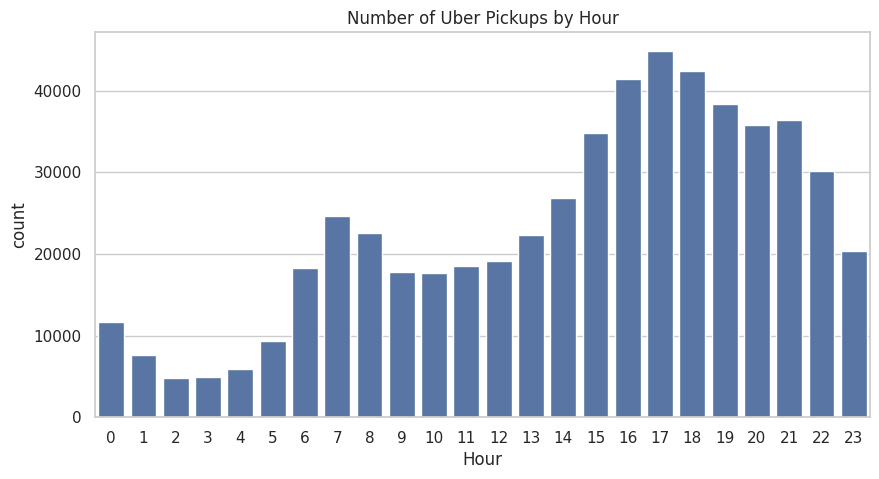

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df)
plt.title('Number of Uber Pickups by Hour')
plt.show()

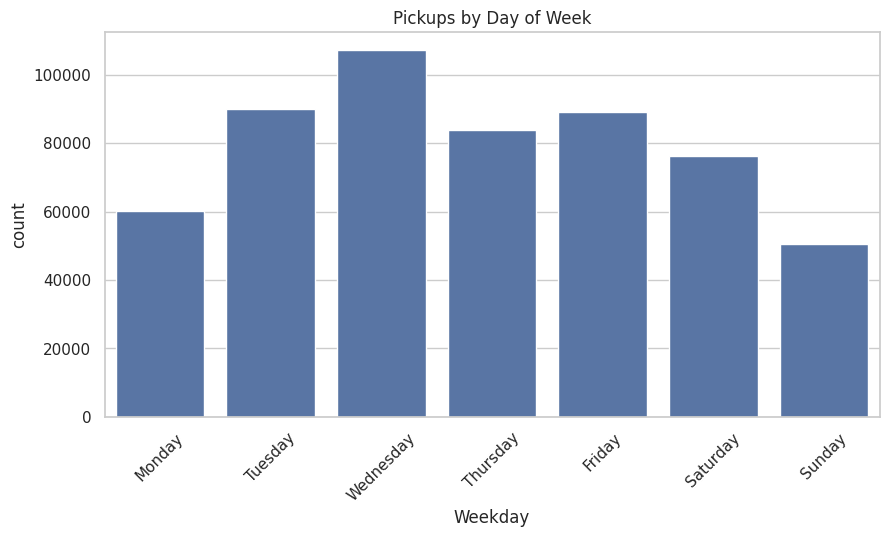

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='Weekday', data=df, order=[
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
plt.title('Pickups by Day of Week')
plt.xticks(rotation=45)
plt.show()

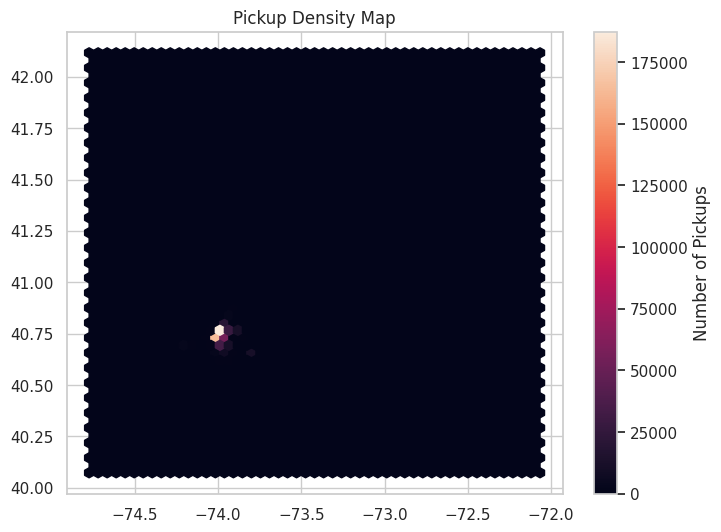

In [11]:
plt.figure(figsize=(8,6))
plt.hexbin(df['Lon'], df['Lat'], gridsize=50)
plt.colorbar(label='Number of Pickups')
plt.title('Pickup Density Map')
plt.show()

In [12]:
df.to_csv('cleaned_uber_data.csv', index=False)